<a href="https://colab.research.google.com/github/larscaspersen/phenoflex_meets_bayes/blob/main/phenoflex_with_hazard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -q numpyro==0.14.0 jax==0.4.26 jaxlib==0.4.26 arviz causalgraphicalmodels daft
!pip install -q numpyro jax jaxlib arviz causalgraphicalmodels daft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 12.3 MB/s eta 0:00:00


In [2]:
# %%
import argparse
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import arviz as az
import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
# Building on numpyro AR2 example: https://num.pyro.ai/en/latest/examples/ar2.html
import pandas as pd

Example data from the chillR package

In [3]:
#read example files
url = "https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_bloom.csv"
KA_bloom = pd.read_csv(url)

KA_temp_hourly = pd.read_csv("https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_hourtemps.csv")

#KA_temp_hourly.head()
KA_bloom = KA_bloom.dropna()

KA_temp_hourly['Year'].min()

1998

In [4]:
#taken from ChatGPT
def gen_season_list(temps, mrange=(8, 6), years=None):
    """
    Python equivalent of chillR::genSeasonList

    Parameters:
        temps (pd.DataFrame): Must contain columns ['Year', 'Month', 'Temp', 'JDay']
        mrange (tuple): (start_month, end_month), e.g. (8, 6)
        years (list or iterable): Years to generate seasons for

    Returns:
        list of pd.DataFrame
    """

    assert len(mrange) == 2, "mrange must have length 2"
    assert years is not None, "years must be provided"
    assert temps is not None, "temps must be provided"
    assert mrange[0] > mrange[1], "start month must be greater than end month"

    start_month, end_month = mrange
    season_list = []

    for y in years:
        # Previous year portion (start_month → Dec)
        prev_mask = (
            (temps["Month"].between(start_month, 12)) &
            (temps["Year"] == y - 1)
        )

        # Current year portion (Jan → end_month)
        curr_mask = (
            (temps["Month"].between(1, end_month)) &
            (temps["Year"] == y)
        )

        season_df = temps.loc[prev_mask | curr_mask, ["Temp", "JDay", "Year"]].copy()

        season_list.append(season_df)

    return season_list

Test the python version of PhenoFkex

# **PhenoFlex for Numpyro**

The cases in PhenoFlex where coded with jnp.where (e.g. when we check for temperature thresholds or when we check for the 1.0 threshold for conversion)

In addition a smooth bloom date is returned with a function expressing the difference to heat requirement. When accumulated heat is too low or exceed the threshold too much, then it is penalized. I need to penalize too high heat aswell, otherwise the function is waiting until the difference is maximized


In [5]:
import numpyro.distributions as dist
from numpyro.distributions import constraints
from jax.nn import sigmoid
from jax import lax
import jax.numpy as jnp # Ensure jnp is imported

# ── JAX helpers (vectorised, no Python loops) ─────────────────────────────────

def _p1z_jax(T, Tu, Tb, Tc):
    in_lower = (T >= Tb) & (T <= Tu)
    in_upper = (T > Tu) & (T <= Tc)
    val_lower = 0.5 * (1 + jnp.cos(jnp.pi + jnp.pi * (T - Tb) / (Tu - Tb)))
    val_upper = 1 + jnp.cos(jnp.pi / 2 + jnp.pi / 2 * (T - Tu) / (Tc - Tu))
    return jnp.where(in_lower, val_lower, jnp.where(in_upper, val_upper, 0.0))

def _p2z_jax(T, Tu, Delta):
    return jnp.exp(-((T - Tu) / (2 * Delta)) ** 2)

def _pfcn_jax(T, Tf, slope):
   # Guard against T=0 (occurs at season start when y_prev=0)
    T_safe = jnp.where(T == 0.0, 1.0, T)  # safe value for division; masked out below
    x = slope * Tf * (T_safe - Tf) / T_safe
    sr = jnp.exp(jnp.clip(x, -20, 17))
    result = jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))
    return jnp.where(T == 0.0, 0.0, result)  # when y=0, no forcing

    #x = slope * Tf * (T - Tf) / T
    #sr = jnp.exp(jnp.clip(x, -20, 17))
    #return jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))

# ── Hazard function ─────────────────────────────────────────────────
#used to compare predicted and observed bloom
#processes accumulated heat and returns a predicted bloom date
#based on event analysis
def discrete_hazard_loglik(z_trace, bloom_step, zc, k):
    """
    Log-likelihood of observing bloom at bloom_step under a
    discrete-time survival model.

    Parameters
    ----------
    z_trace   : jnp array (N,) — cumulative heat units at each time step
    bloom_step: int — observed index at which bloom occurred
    zc        : scalar — heat requirement threshold (sampled parameter)
    k         : scalar — logistic sharpness (sampled parameter)

    Returns
    -------
    Scalar log-likelihood
    """
    # Hazard at each step: probability of blooming NOW given survival
    hazards = sigmoid(k * (z_trace - zc))          # shape (N,)

    # Calculate log_survival using boolean masking
    # Create a mask for indices up to (but not including) bloom_step
    # jnp.arange(hazards.shape[0]) creates [0, 1, ..., N-1]
    # (jnp.arange(hazards.shape[0]) < bloom_step) creates a boolean mask [True, True, ..., False, False]
    mask = jnp.arange(hazards.shape[0]) < bloom_step

    # Apply the mask: only sum jnp.log1p(-hazards) where mask is True
    # For elements where mask is False, jnp.where returns 0.0, which doesn't affect the sum
    log_survival = jnp.sum(jnp.where(mask, jnp.log1p(-hazards), 0.0))

    # Log hazard at the bloom step
    log_hazard_at_bloom = jnp.log(hazards[bloom_step])

    return log_survival + log_hazard_at_bloom

# make forward prediction (when there is no observation)
def expected_bloom_time(z_trace, hours, zc, k):
    hazards  = sigmoid(k * (z_trace - zc))
    survival = jnp.cumprod(1 - hazards)
    pmf      = jnp.concatenate([
        jnp.array([hazards[0]]),
        survival[:-1] * hazards[1:]
    ])
    pmf = pmf / pmf.sum() # Ensure PMF sums to 1
    expected_hour = jnp.dot(pmf, hours)
    most_likely_hour = hours[jnp.argmax(pmf)] # Mode of the PMF
    return expected_hour, pmf, most_likely_hour

#phenofelx model with hazard function to calculate bloom
def phenoflex_numpyro_hazard(
    temp,
    times,
    bloom_index=None,
    Imodel=0,
    deg_celsius=True,
    return_traces=False, # New flag for conditional return
):
    """
    Numpyro probabilistic wrapper around PhenoFlex.

    The forward pass accumulates heat (z) over the season. Hazard function calculates
    likelihood of bloom at the day of observation, given the accumulated heat and
    the estimated heat requirement.

    Parameters
    ----------
    temp          : jnp array of hourly temperatures, length N or (num_seasons, N)
    times         : jnp array of hours since season start, length N or (num_seasons, N)
                    e.g. [0, 1, 2, ..., N-1] for consecutive hourly records
    bloom_index : time-step when bloom was recorded.
                    Pass None for prior predictive / generative mode.
    Imodel        : 0 = GDH triangular bell, 1 = Gaussian
    deg_celsius   : True if temperatures arrive in Celsius
    sharpness     : steepness of the soft bloom-date estimator.
                    Increase if the posterior is diffuse; decrease if gradients vanish.
    return_traces : If True, x_trace, y_trace, and z_trace will be returned as deterministic outputs.
    """

    # ── Priors ────────────────────────────────────────────────────────────────
    # mcmc chooses negative yc value and then the model is essentially a single-forcing model
    #yc    = numpyro.sample("yc",    dist.Normal(65.0,  10.0))
    yc    = numpyro.sample("yc",    dist.LogNormal(jnp.log(65.0), 0.3))
    zc    = numpyro.sample("zc",    dist.Normal(220.0, 30.0))
    k     = numpyro.sample("k",     dist.LogNormal(0.0, 1.0))
    s1    = numpyro.sample("s1",    dist.Beta(2.0, 2.0))
    E0    = numpyro.sample("E0",    dist.Normal(4153.5, 200.0))
    E1    = numpyro.sample("E1",    dist.Normal(12888.8, 500.0))
    A0    = numpyro.sample("A0",    dist.HalfNormal(139500)) # Changed to HalfNormal as values are positive
    A1    = numpyro.sample("A1",    dist.HalfNormal(2.567e18)) # Changed to HalfNormal
    Tf    = numpyro.sample("Tf",    dist.Normal(4.0,   1.0))
    slope = numpyro.sample("slope", dist.HalfNormal(1.6))
    Tb    = numpyro.sample("Tb",    dist.Normal(4.0,   2.0))
    Tu    = numpyro.sample("Tu",    dist.Normal(26.0,  3.0))
    Tc    = numpyro.sample("Tc",    dist.Normal(36.0,  3.0))
    Delta = numpyro.sample("Delta", dist.HalfNormal(5.0))

    # Ensure temp and times are at least 1D arrays, and if they are single season, make them 2D
    if temp.ndim == 1:
        temp = temp[None, :]
        times = times[None, :]
        if bloom_index is not None: # only make obs 1D if it's not None
            bloom_index = jnp.atleast_1d(bloom_index)

    num_seasons = temp.shape[0]

    # Convert threshold temperatures to Kelvin
    offset = 273.0 if deg_celsius else 0.0
    _Tf = Tf + offset
    _Tu = Tu + offset
    _Tc = Tc + offset
    _Tb = Tb + offset

    # ── Forward pass via scan ─────────────────────────────────────────────────
    # dt will be (num_seasons, N-1)
    dt = times[:, 1:] - times[:, :-1]

    def transition(carry, inputs):
        x_prev, y_prev, z_prev = carry
        ti_raw, dt_i = inputs # ti_raw and dt_i are now (num_seasons,)

        ti = ti_raw + offset

        # Ensure A0, A1, E0, E1, etc. are broadcastable if they are scalars from priors
        xs_i = A0 / A1 * jnp.exp(-(E0 - E1) / ti)
        k1   = A1 * jnp.exp(-E1 / ti)

        x_new = xs_i - (xs_i - x_prev) * jnp.exp(-k1 * dt_i)
        y_new = y_prev

        heat_rate = _p1z_jax(ti, _Tu, _Tb, _Tc) if Imodel == 0 else _p2z_jax(ti, _Tu, Delta)
        z_new = z_prev + heat_rate * _pfcn_jax(y_prev, yc, s1) * dt_i

        # Labile -> stable chill conversion
        delta   = _pfcn_jax(ti, _Tf, slope) * x_new
        convert = jnp.where(x_new >= 1.0, 1.0, 0.0)
        y_new   = y_new + convert * delta
        x_new   = x_new - convert * delta

        return (x_new, y_new, z_new), (x_new, y_new, z_new) # Return all states to be traced

    # Initial state for each season is (num_seasons,)
    init   = (jnp.zeros(num_seasons), jnp.zeros(num_seasons), jnp.zeros(num_seasons))
    # Inputs for scan need to be (num_time_steps, num_seasons) if we want to iterate over time
    # So we transpose temp[:, :-1] and dt
    inputs = (temp[:, :-1].T, dt.T)

    (_, _, _), (x_trace, y_trace, z_trace) = scan(transition, init, inputs)
    # x_trace, y_trace, z_trace will be (num_time_steps, num_seasons)
    # We want them back as (num_seasons, num_time_steps)
    x_trace = x_trace.T
    y_trace = y_trace.T
    z_trace = z_trace.T

    if return_traces:
        numpyro.deterministic("x_trace", x_trace)
        numpyro.deterministic("y_trace", y_trace)
        numpyro.deterministic("z_trace", z_trace)

    # ── Likelihood (training) or prediction ───────────────────────────────────
    if bloom_index is not None:
        log_liks = jax.vmap(
            lambda z, t: discrete_hazard_loglik(z, t, zc, k)
        )(z_trace, bloom_index)
        numpyro.factor("bloom_obs", jnp.sum(log_liks))
    else:
        # Prediction mode: return expected bloom time per season
        # `expected_bloom_time` now returns a tuple: (expected_hour, pmf, most_likely_hour)
        expected_hours, pmfs, most_likely_hours = jax.vmap(
            lambda z, h: expected_bloom_time(z, h, zc, k)
        )(z_trace, times[:, 1:])

        numpyro.deterministic("bloom_hour_pred", expected_hours)
        numpyro.deterministic("bloom_pmf_pred", pmfs) # This will be (num_seasons, num_timesteps-1) and represents the likelihood distribution
        numpyro.deterministic("most_likely_bloom_hour_pred", most_likely_hours)


In [6]:
# Helpers ───────────────────────────────────────────────────────────────────

def gen_season_list(temps, mrange=(8, 6), years=None):
    """Python equivalent of chillR::genSeasonList."""
    assert len(mrange) == 2 and mrange[0] > mrange[1]
    assert years is not None and temps is not None
    start_month, end_month = mrange

    return [
        temps.loc[
            ((temps["Month"].between(start_month, 12)) & (temps["Year"] == y - 1)) |
            ((temps["Month"].between(1, end_month))    & (temps["Year"] == y)),
            ["Temp", "JDay", "Year"]
        ].copy()
        for y in years
    ]


def prepare_seasons_hazard(season_list, bloom_df, years):
    """
    Pad seasons to a common length and return stacked JAX arrays
    ready to pass into phenoflex_numpyro_hazard.

    Returns
    -------
    temps        : (S, T) float32
    times        : (S, T) float32
    bloom_indices: (S,)   int
    """
    # Ensure season_list and years have consistent lengths
    if len(season_list) != len(years):
        raise ValueError(
            f"The `season_list` must contain one entry for each year in the `years` argument. "
            f"Expected {len(years)} seasons, but got {len(season_list)}."
        )

    # Check for empty season dataframes
    for i, season_df in enumerate(season_list):
        if season_df.empty:
            raise ValueError(
                f"Season data for year {years[i]} is empty. This indicates a lack of temperature data for that season."
            )

    max_len = max(len(s) for s in season_list)
    if max_len == 0:
        raise ValueError("All seasons in `season_list` are empty. Cannot prepare data.")

    padded_temps, padded_times = [], []

    for season_df in season_list:
        temp  = jnp.asarray(season_df.Temp.values, dtype=jnp.float32)
        times_local = jnp.arange(len(temp), dtype=jnp.float32) # Use local variable to avoid confusion
        pad   = max_len - len(temp)

        padded_temps.append(
            jnp.pad(temp,  (0, pad), mode="edge") if pad else temp
        )
        padded_times.append(
            jnp.concatenate([times_local, times_local[-1] + jnp.arange(1, pad + 1, dtype=jnp.float32)])
            if pad else times_local
        )

    # Filter bloom_df for the requested years and drop NaNs
    filtered_bloom_pheno = bloom_df[bloom_df["Year"].isin(years)][["Year", "pheno"]].set_index("Year")
    bloom_doys_series = filtered_bloom_pheno.reindex(years)["pheno"]

    missing_bloom_data_years = bloom_doys_series[bloom_doys_series.isna()].index.tolist()
    if missing_bloom_data_years:
        raise ValueError(
            f"No valid bloom observation found for years: {sorted(missing_bloom_data_years)}. "
            f"These years must be present in `bloom_df` and have non-NaN 'pheno' values."
        )

    observed_bloom_doys = jnp.asarray(bloom_doys_series.values, dtype=jnp.float32)

    bloom_indices = []
    for i_season, season_df in enumerate(season_list):
        observed_bloom_doy = observed_bloom_doys[i_season]
        season_bloom_year = years[i_season] # The calendar year of the observed bloom

        # Find all indices where JDay matches observed_bloom_doy AND Year matches season_bloom_year
        # .values is used to convert pandas Series to numpy array for jnp.where
        match_mask = (season_df['JDay'] == observed_bloom_doy) & (season_df['Year'] == season_bloom_year)
        all_matching_hourly_indices = jnp.where(match_mask.values)[0]

        if len(all_matching_hourly_indices) == 0:
            raise ValueError(
                f"No matching JDay found for observed bloom DOY {observed_bloom_doy} in season {season_bloom_year}. "
                f"This might indicate an issue with the observed bloom data or temperature data range."
            )
        # Assume bloom recorded at noon (12th hour, which is index 11 for 0-indexed hours)
        if len(all_matching_hourly_indices) < 12:
             raise ValueError(
                f"Less than 12 hourly records found for bloom day {observed_bloom_doy} in season {season_bloom_year}. "
                f"Cannot determine noon (index 11) bloom hour reliably. Found {len(all_matching_hourly_indices)} records."
            )

        # Take the index corresponding to the 12th hour (index 11) of the bloom day
        bloom_index_for_season = all_matching_hourly_indices[11].astype(int)

        # Ensure the index is within the bounds of the actual (unpadded) season data length
        actual_season_len = len(season_list[i_season]) # Length of original season_df before padding
        bloom_index_for_season = jnp.clip(bloom_index_for_season, 0, actual_season_len - 1)

        bloom_indices.append(bloom_index_for_season)

    return (
        jnp.stack(padded_temps),
        jnp.stack(padded_times),
        jnp.asarray(bloom_indices, dtype=jnp.int32)
    )


I fixed all parameters except yc, zc, s1. You can run the model several times, here I used `num_sample = 20`

The function can process several seasons of temperature at once

In [ ]:
FIXED_PARAMS = dict(
    #yc=-3.24,
    #zc=99.47,
    #s1=0.57,
    k = 0.2,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────

years = np.arange(2005,2007)
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, bloom_index = prepare_seasons_hazard(
    seasons, KA_bloom, years
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Bloom Index  : {bloom_index}")


conditioned_model = numpyro.handlers.condition(phenoflex_numpyro_hazard, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=10)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps,
    times=times,
    #bloom_index=bloom_index,
    Imodel=0,
    return_traces=True,
)

Temps shape : (2, 8016)
Times shape : (2, 8016)
Bloom Index  : [6179 6443]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp

# --- This old plotting block is commented out to avoid duplication with the new diagnostic plots ---
"""
bloom_pmf_pred = preds['bloom_pmf_pred']
num_samples = bloom_pmf_pred.shape[0]
num_seasons = bloom_pmf_pred.shape[1]
num_timesteps_minus_1 = bloom_pmf_pred.shape[2]

fig, axes = plt.subplots(num_seasons, 1, figsize=(15, 4 * num_seasons), sharex=True)
if num_seasons == 1:
    axes = [axes]

for i_season in range(num_seasons):
    ax = axes[i_season]
    pmfs_for_season = bloom_pmf_pred[:, i_season, :]
    mean_pmf = jnp.mean(pmfs_for_season, axis=0)
    lower_pmf = jnp.percentile(pmfs_for_season, 5, axis=0)
    upper_pmf = jnp.percentile(pmfs_for_season, 95, axis=0)
    hours_for_plotting = times[i_season, 1:]

    ax.plot(hours_for_plotting, mean_pmf, label='Mean PMF of Bloom', color='blue')
    ax.fill_between(hours_for_plotting, lower_pmf, upper_pmf, color='blue', alpha=0.2, label='90% CI of PMF')

    if bloom_index is not None:
        observed_idx = bloom_index[i_season]
        ax.axvline(x=observed_idx, color='red', linestyle='--', label=f'Observed Bloom Index: {observed_idx}')

    ax.set_title(f'Season {years[i_season]} - Bloom Probability Distribution')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
"""
print("Old plotting cell disabled. Use plot_phenoflex_diagnostics() for visualization.")

Old plotting cell disabled. Use plot_phenoflex_diagnostics() for visualization.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
from jax.nn import sigmoid
import numpy as np

def plot_phenoflex_diagnostics(
    preds,
    times,
    seasons,
    years,
    bloom_index=None,
    season_idx: int = 0,
    sample_idx: int = 0,
    zc_override=None,
    k_override=None,
    jday_range=(90, 140),
):
    """
    Three-panel diagnostic plot for one PhenoFlex season.

    Panels
    ------
    1. Accumulated heat z(t) with zc threshold and observed bloom
    2. Instantaneous hazard h(t) = σ(k · (z − zc))
    3. Survival S(t) and bloom PMF

    Parameters
    ----------
    preds        : dict returned by numpyro Predictive (or condition + scan)
    times        : (S, T) array of hourly times from prepare_seasons_hazard
    seasons      : list of DataFrames from gen_season_list
    years        : array of season years
    bloom_index  : (S,) int array from prepare_seasons_hazard, or None
    season_idx   : which season (row) to visualise
    sample_idx   : which posterior sample to use for z_trace
    zc_override  : use a fixed zc instead of reading from preds
    k_override   : use a fixed k instead of reading from preds
    jday_range   : (min_jday, max_jday) for x-axis zoom
    """
    # ── Extract traces ────────────────────────────────────────────────────────
    z_trace = np.array(preds["z_trace"][sample_idx, season_idx])   # (T-1,)
    y_trace = np.array(preds["y_trace"][sample_idx, season_idx])
    x_trace = np.array(preds["x_trace"][sample_idx, season_idx])

    # zc and k can come from preds (shape: num_samples) or fixed overrides
    zc = float(zc_override) if zc_override is not None else float(preds["zc"][sample_idx])
    k  = float(k_override)  if k_override  is not None else float(preds["k"][sample_idx])

    # ── Time axis  ────────────────────────────────────────────────────────────
    # z_trace has length T-1 (output of scan over dt), matching times[:, 1:]
    hours = np.array(times[season_idx, 1:])          # (T-1,)
    N     = len(hours)

    # Build a JDay lookup for the x-axis ticks
    season_df     = seasons[season_idx]
    jday_values   = season_df["JDay"].values
    pad           = times.shape[1] - len(jday_values)
    if pad > 0:
        jday_lookup = np.concatenate([jday_values,
                                      np.full(pad, jday_values[-1])])
    else:
        jday_lookup = jday_values
    # jday_lookup is indexed by hour index (0..T-1); hours are 1..T-1
    jday_at_step = jday_lookup[hours.astype(int)]

    def make_ticks(ax):
        lo, hi = jday_range
        mask = (jday_at_step >= lo) & (jday_at_step <= hi)
        h_in  = hours[mask]
        jd_in = jday_at_step[mask]
        if len(h_in) == 0:
            return
        ax.set_xlim(h_in[0], h_in[-1])
        uniq_jd, first_idx = np.unique(jd_in, return_index=True)
        tick_h = h_in[first_idx]
        step   = max(1, len(tick_h) // 10)
        ax.set_xticks(tick_h[::step])
        ax.set_xticklabels([f"J{int(j)}" for j in uniq_jd[::step]],
                           rotation=45, ha="right", fontsize=9)

    # ── Hazard / survival / PMF ───────────────────────────────────────────────
    hazards  = 1 / (1 + np.exp(-k * (z_trace - zc)))            # sigmoid
    survival = np.cumprod(1 - hazards)
    survival = np.concatenate([[1.0], survival[:-1]])            # S(t) before step t
    pmf      = survival * hazards
    pmf      = pmf / pmf.sum()

    bloom_step = int(bloom_index[season_idx]) if bloom_index is not None else None

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 10))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)

    BLOOM_COLOR  = "#E24B4A"
    Z_COLOR      = "#378ADD"
    ZC_COLOR     = "#E24B4A"
    HAZ_COLOR    = "#D85A30"
    SURV_COLOR   = "#1D9E75"
    PMF_COLOR    = "#7F77DD"

    year_label = years[season_idx]

    gs = gridspec.GridSpec(4, 1, hspace=0.45)
    gs[0]  # → ax0 (temperature)
    gs[1]  # → ax1 (z accumulation)
    gs[2]  # → ax2 (hazard)
    gs[3]  # → ax3 (survival + PMF)

    #time of predicted flowering
    mode_step = int(np.argmax(pmf))

    # ── Panel 0: temperature ──────────────────────────────────────────────────
    temp_vals = np.array(seasons[season_idx]["Temp"].values)
    temp_hours = np.array(times[season_idx, :len(temp_vals)])

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(temp_hours, temp_vals, color="#888780", lw=0.8, alpha=0.7,
             label="hourly temperature")

    if bloom_step is not None:
        ax0.axvline(hours[bloom_step], color=BLOOM_COLOR, lw=1.0, ls=":",
                    alpha=0.6, label="observed bloom")
    ax0.axvline(hours[mode_step], color=PMF_COLOR, lw=1.0, ls="-.",
        alpha=0.8, label=f"PMF mode  J{int(jday_at_step[mode_step])}")

    ax0.set_ylabel("temperature (°C)")
    ax0.legend(fontsize=9, loc="upper right", ncol=2)
    ax0.grid(True, alpha=0.25)
    make_ticks(ax0)

    # ── Panel 1: z accumulation ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[1])
    ax1.plot(hours, z_trace, color=Z_COLOR, lw=1.8, label="z (accumulated heat)")
    ax1.axhline(zc, color=ZC_COLOR, lw=1.2, ls="--", label=f"zc = {zc:.1f}")
    if bloom_step is not None:
        ax1.axvline(hours[bloom_step], color=BLOOM_COLOR, lw=1.0, ls=":",
                    alpha=0.6, label=f"observed bloom (step {bloom_step})")
       # ax1.scatter([hours[bloom_step]], [z_trace[bloom_step]],
       #             color=BLOOM_COLOR, zorder=5, s=50)
    ax1.axvline(hours[mode_step], color=PMF_COLOR, lw=1.0, ls="-.",
            alpha=0.8, label=f"PMF mode  J{int(jday_at_step[mode_step])}")
    ax1.set_ylim(top=400)
    ax1.set_ylabel("heat units (z)")
    ax1.set_title(f"Season {year_label}  |  sample {sample_idx}  |  "
                  f"k = {k:.3f},  zc = {zc:.1f}")
    ax1.legend(fontsize=9, loc="upper right")
    ax1.grid(True, alpha=0.25)
    make_ticks(ax1)

    # ── Panel 2: hazard ────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2])
    ax2.plot(hours, hazards, color=HAZ_COLOR, lw=1.8,
             label="h(t) = σ(k·(z − zc))")
    if bloom_step is not None:
        ax2.axvline(hours[bloom_step], color=BLOOM_COLOR, lw=1.0, ls=":",
                    alpha=0.6)
        #ax2.scatter([hours[bloom_step]], [hazards[bloom_step]],
        #            color=BLOOM_COLOR, zorder=5, s=50,
        #            label=f"h at bloom = {hazards[bloom_step]:.3f}")
    ax2.axvline(hours[mode_step], color=PMF_COLOR, lw=1.0, ls="-.",
                alpha=0.8, label=f"PMF mode  J{int(jday_at_step[mode_step])}")
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("hazard h(t)")
    ax2.legend(fontsize=9, loc="upper left")
    ax2.grid(True, alpha=0.25)
    make_ticks(ax2)

    # ── Panel 3: survival + PMF (twin axis) ───────────────────────────────────
    ax3 = fig.add_subplot(gs[3])
    ax3_pmf = ax3.twinx()

    ax3.plot(hours, survival, color=SURV_COLOR, lw=1.8, label="survival S(t)")
    if bloom_step is not None:
        ax3.axvline(hours[bloom_step], color=BLOOM_COLOR, lw=1.0, ls=":",
                    alpha=0.6, label="observed bloom")
        #ax3.scatter([hours[bloom_step]], [survival[bloom_step]],
        #            color=BLOOM_COLOR, zorder=5, s=50)

    ax3_pmf.fill_between(hours, pmf, alpha=0.35, color=PMF_COLOR)
    ax3_pmf.plot(hours, pmf, color=PMF_COLOR, lw=1.0, label="bloom PMF")
    ax3_pmf.axvline(hours[mode_step], color=PMF_COLOR, lw=1.0, ls="-.",
                    alpha=0.8, label=f"PMF mode  J{int(jday_at_step[mode_step])}")
    """
    if bloom_step is not None:
        ax3_pmf.scatter([hours[bloom_step]], [pmf[bloom_step]],
                        color=BLOOM_COLOR, zorder=5, s=50)
    """

    ax3.set_ylim(0, 1.05)
    ax3_pmf.set_ylim(0, None)

    ax3.set_ylabel("survival S(t)", color=SURV_COLOR)
    ax3.tick_params(axis="y", labelcolor=SURV_COLOR)
    ax3_pmf.set_ylabel("PMF", color=PMF_COLOR)
    ax3_pmf.tick_params(axis="y", labelcolor=PMF_COLOR)

    ax3.set_xlabel("Julian day")
    ax3.grid(True, alpha=0.25)
    make_ticks(ax3)


    # Combined legend from both axes
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_pmf.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

    fig.align_ylabels([ax0, ax1, ax2, ax3])
    plt.show()
    #return fig

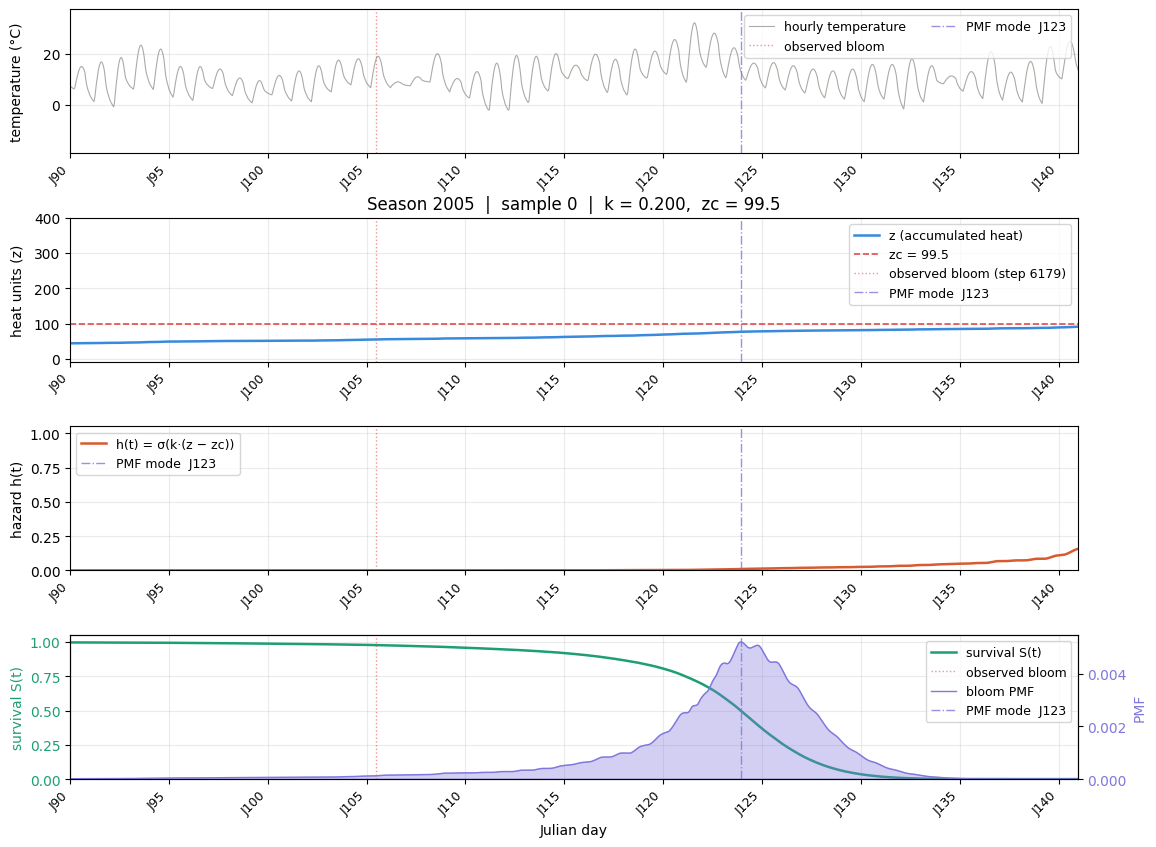

In [ ]:
# single season, first posterior sample
plot_phenoflex_diagnostics(
    preds,
    times,
    seasons,
    years,
    bloom_index=bloom_index,
    season_idx=0,
    sample_idx=0,
    jday_range=(90, 140),
    k_override = 0.2
)

In [ ]:
# 1. Print the entire 'preds' dictionary to see its contents
print("\n--- Full 'preds' dictionary content ---")
print(preds)

# 2. Check the type of 'preds'
print("\n--- Type of 'preds' ---")
print(f"Type of preds: {type(preds)}")

# 3. Get all keys of the 'preds' dictionary
print("\n--- Keys in 'preds' ---")
print(f"Keys: {preds.keys()}")

# 4. Iterate through keys to check shape and type of each element
print("\n--- Structure of each element in 'preds' ---")
for key, value in preds.items():
    if hasattr(value, 'shape') and hasattr(value, 'dtype'):
        print(f"Key: '{key}', Shape: {value.shape}, Dtype: {value.dtype}")
    else:
        print(f"Key: '{key}', Type: {type(value)}")


In [ ]:
# ── Fixed parameters (for prior-predictive / sanity checks) ──────────────────

FIXED_PARAMS = dict(
    #yc=40.0,
    #zc=190.0,
    #s1=0.5,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────

years = np.arange(1999,2007)
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, start_doys, bloom_doys, leap_years = prepare_seasons(
    seasons, KA_bloom, years
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Start DOYs  : {start_doys}")
print(f"Bloom DOYs  : {bloom_doys}")

conditioned_model = numpyro.handlers.condition(phenoflex_numpyro, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=20)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps, times=times, start_doy=start_doys,
    bloom_doy_obs=bloom_doys,
    sharpness=1, Imodel=0,
    leap_years=leap_years,
    return_traces=True,
)

print("\nPredicted bloom DOY:", preds["bloom_doy_pred"])

Visualize the variaiton of the repetitions

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# --- This plotting block is commented out to avoid duplication ---
"""
def get_soft_bloom_hour_and_weights(z_trace_single_season, hours_single_season, zc_scalar, sharpness):
    logits  = -sharpness * (z_trace_single_season - zc_scalar)**2
    logits  = logits - jnp.max(logits)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights)
    bloom_hour_val = jnp.dot(weights, hours_single_season)
    return bloom_hour_val, weights

num_samples_in_preds = preds['z_trace'].shape[0]
num_seasons_in_preds = preds['z_trace'].shape[1]
mean_zc = preds['zc'].mean()

for i_season in range(num_seasons_in_preds):
    z_trace_all_samples = preds['z_trace'][:, i_season, :]
    y_trace_all_samples = preds['y_trace'][:, i_season, :]
    bloom_doy_pred_all_samples = preds['bloom_doy_pred'][:, i_season]
    mean_z_trace = jnp.mean(z_trace_all_samples, axis=0)
    lower_z_trace = jnp.percentile(z_trace_all_samples, 5, axis=0)
    upper_z_trace = jnp.percentile(z_trace_all_samples, 95, axis=0)
    mean_bloom_doy_pred = jnp.mean(bloom_doy_pred_all_samples)
    hours_for_plotting = times[i_season, 1:]
    bloom_hour_mean_z = get_soft_bloom_hour_and_weights(mean_z_trace, hours_for_plotting, mean_zc, sharpness=1.0)[0]
    season_year = years[i_season]
    observed_bloom_doy_val = bloom_doys[i_season]
    start_doy_val = start_doys[i_season]
    current_season_leap_year_info = leap_years[i_season-1]
    days_in_current_year_for_bloom = jnp.where(current_season_leap_year_info, 366.0, 365.0)
    adjusted_observed_bloom_doy = jnp.where(observed_bloom_doy_val < start_doy_val, observed_bloom_doy_val + days_in_current_year_for_bloom, observed_bloom_doy_val)
    observed_bloom_hour = (adjusted_observed_bloom_doy - start_doy_val + 0.5) * 24.0

    fig, ax1 = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f'Season: {season_year} (Mean and 90% CI)', fontsize=16)
    ax1.plot(hours_for_plotting, mean_z_trace, label='Mean Accumulated Heat')
    ax1.fill_between(hours_for_plotting, lower_z_trace, upper_z_trace, alpha=0.3)
    ax1.axhline(mean_zc, color='r', linestyle='--')
    ax1.axvline(bloom_hour_mean_z, color='g', linestyle='-.')
    ax1.axvline(observed_bloom_hour, color='b', linestyle=':')
    ax1.set_ylabel('Accumulated Heat')
    ax1.legend()
    ax1.grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
"""
print("Old automated plotting loop in cell 901c0e31 disabled.")

In [ ]:
import jax.numpy as jnp

# Extract predicted and observed bloom DOYs
predicted_bloom_doys = preds["bloom_doy_pred"]
observed_bloom_doys = preds["bloom_doy"]

# Ensure observed_bloom_doys is broadcastable (it's already (1, num_seasons))
# If it were (num_seasons,) we'd need observed_bloom_doys[None, :]

# Calculate the difference for each sample and each season
differences = predicted_bloom_doys - observed_bloom_doys

#print("Differences (Predicted - Observed) per sample and season:\n", differences)


# Calculate the mean absolute difference across all samples and seasons
mean_abs_difference = jnp.mean(jnp.abs(differences))

print(f"\nMean Absolute Difference between predicted and observed flowering dates: {mean_abs_difference:.2f} days")

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Flatten the differences array to get all errors in a single 1D array
flat_differences = differences.flatten()

plt.figure(figsize=(10, 6))
plt.hist(flat_differences, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Prediction Errors (Predicted - Observed Bloom DOY)')
plt.xlabel('Prediction Error (days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(jnp.mean(flat_differences), color='red', linestyle='dashed', linewidth=1, label=f'Mean Error: {jnp.mean(flat_differences):.2f}')
plt.axvline(0, color='black', linestyle='dashed', linewidth=1, label = 'Perfect agreement')
plt.legend()
plt.show()

Run the model with example temperature time series. the argument return_traces allows to return the modeled subprocesses. The function returns the bloomdate.

In [ ]:
FIXED_PARAMS = dict(
    #yc=40.0,
    #zc=190.0,
    #s1=0.5,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────

years = np.arange(1999,2007) # Changed from 2010 to 2009 to match bloom_doy_obs length
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, start_doys, bloom_doys, leap_years = prepare_seasons(
    seasons, KA_bloom, years
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Start DOYs  : {start_doys}")
print(f"Bloom DOYs  : {bloom_doys}")

conditioned_model = numpyro.handlers.condition(phenoflex_numpyro, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=1)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps, times=times, start_doy=start_doys,
    bloom_doy_obs=bloom_doys,
    sharpness=1, Imodel=0,
    leap_years=leap_years,
    return_traces=False,
)

In [ ]:
preds

This functions is wrapping the model so that the MCMC sanling can uinteract with it

In [ ]:
def run_inference(model, args, rng_key, dat):
    start = time.time()
    sampler = numpyro.infer.NUTS(model)
    mcmc = numpyro.infer.MCMC(
        sampler,
        num_warmup=args['num_warmup'],
        num_samples=args['num_samples'],
        num_chains=args['num_chains'],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, **dat)
    mcmc.print_summary()
    az_mcmc = az.from_numpyro(mcmc)
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc, mcmc.get_samples(), az_mcmc

Run the mcmc sampling with a random sample of yc, zc, s1 as a starting point?

In [ ]:
print('dimensions of temps: ', temps.shape)
print('dimensions of times: ',times.shape)
print('dimensions of start_doy: ',start_doys.shape)
print('dimensions of bloom_doys: ',bloom_doys.shape)

In [ ]:
# Prepare the 'dat' dictionary for phenoflex_numpyro
# Reusing the data prepared in previous cells (e.g., from plSeY2Y-C2NC)
dat_phenoflex = {
    'temp': temps,
    'times': times,
    'start_doy': start_doys,
    'bloom_doy_obs': bloom_doys,
    'leap_years': leap_years,
    'sharpness': 1, # Using the same sharpness as in the predictive run
    'Imodel': 0    # Using the same Imodel as in the predictive run
}

# Define args for run_inference
args_phenoflex = {}
args_phenoflex['num_warmup'] = 1000
args_phenoflex['num_samples'] = 1000
args_phenoflex['num_chains'] = 2

# Set the model to phenoflex_numpyro
model_phenoflex = phenoflex_numpyro

# Condition the model with fixed parameters as done previously (e.g., in qmpen104LyfF)
conditioned_model_phenoflex = numpyro.handlers.condition(model_phenoflex, data=FIXED_PARAMS)

# Run the inference
mcmc_phenoflex, mcmc_samples_phenoflex, az_mcmc_phenoflex = run_inference(conditioned_model_phenoflex, args_phenoflex, rng_key, dat_phenoflex)

Rhat is kinda high, so that is not great. Also the estimated heatz requirement is very low (and the sd is high)

In [ ]:
flat_yc = mcmc_samples_phenoflex['yc'].flatten()
flat_zc = mcmc_samples_phenoflex['zc'].flatten()
flat_s1 = mcmc_samples_phenoflex['s1'].flatten()
flat_sigma = mcmc_samples_phenoflex['sigma'].flatten()

#plt.figure(figsize=(10, 6))
#plt.hist(flat_differences, bins=20, edgecolor='black', alpha=0.7)
#plt.title('Histogram of Prediction Errors (Predicted - Observed Bloom DOY)')
#plt.xlabel('Prediction Error (days)')
#plt.ylabel('Frequency')
#plt.grid(axis='y', alpha=0.75)
#plt.axvline(jnp.mean(flat_differences), color='red', linestyle='dashed', linewidth=1, label=f'Mean Error: {jnp.mean(flat_differences):.2f}')
#plt.axvline(0, color='black', linestyle='dashed', linewidth=1, label = 'Perfect agreement')
#plt.legend()
#plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # Increased figsize for better visibility

# First plot (yc)
axes[0, 0].hist(flat_yc, bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Chill requirement (yc)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of yc')

# Second plot (zc)
axes[0, 1].hist(flat_zc, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Heat requirement (zc)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of zc')

# Third plot (s1)
axes[1, 0].hist(flat_s1, bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Slope of transition function (s1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of s1')

# Fourth plot (sigma)
axes[1, 1].hist(flat_sigma, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Error term (sigma)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of sigma')

plt.tight_layout()
plt.show()

In [ ]:
from numpyro.infer.util import potential_energy
import jax

test_params = {"yc": 65.0, "zc": 220.0, "s1": 0.5, "sigma": 3.0}

pe = potential_energy(conditioned_model_phenoflex, (), dat_phenoflex, test_params)
print("Potential energy:", pe)  # Must be finite

grads = jax.grad(potential_energy, argnums=3)(
    conditioned_model_phenoflex, (), dat_phenoflex, test_params
)
for k, v in grads.items():
    print(f"grad {k}: {v}")

so the gradient for s1 and yc is nan, that might be the reason why the algorithm cannot find initial parameters

In [ ]:
import seaborn as sns
import pandas as pd

# Plot the posterior
plot_data = {
    's1': mcmc_samples_phenoflex['s1'],
    'sigma': mcmc_samples_phenoflex['sigma'],
    'yc': mcmc_samples_phenoflex['yc'],
    'zc': mcmc_samples_phenoflex['zc']
}
g = sns.PairGrid(pd.DataFrame.from_dict(plot_data))
g.map_lower(plt.scatter,s=0.1)
g.map_diag(sns.histplot, lw=3, legend=False)
# Hide upper plots of grid
def hide_current_axis(*args, **kwds):
    plt.gca().set_visible(False)
g.map_upper(hide_current_axis);

In [ ]:
az.plot_posterior(plot_data);

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp

# Get predicted bloom DOYs from MCMC samples
predicted_bloom_doys_mcmc = mcmc_samples_phenoflex['bloom_doy_pred'] # Shape: (num_samples, num_seasons)

# Get observed bloom DOYs and years from the data preparation step
# These variables (bloom_doys, years) should be available from previous cells like plSeY2Y-C2NC or qmpen104LyfF
# If not, you might need to re-run the cell where they are defined.

num_seasons = predicted_bloom_doys_mcmc.shape[1]

plt.figure(figsize=(15, 5 * num_seasons))

for i_season in range(num_seasons):
    predicted_for_season = predicted_bloom_doys_mcmc[:, i_season]
    observed_for_season = bloom_doys[i_season]
    year_for_season = years[i_season]

    plt.subplot(num_seasons, 1, i_season + 1)
    sns.histplot(predicted_for_season, kde=True, stat='density', bins=30, label='Predicted Bloom DOY Distribution')
    plt.axvline(observed_for_season, color='red', linestyle='--', label=f'Observed Bloom DOY: {observed_for_season:.1f}')
    plt.title(f'Bloom Date Prediction for Season {year_for_season}')
    plt.xlabel('Bloom Day of Year (DOY)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(seasons[0].head())
print(seasons[0].tail())

The crazy-late predictions are actually crazy-early predictions where the model uses negative or close to zero heat requirements and immediately returns a bloom date. Problem is, that this bloom date is kinda close (not really though) as the actual bloom date and gradually increasing it makes prediction errro worse, because the predicted bloom date increases. (and thus it distances from the observation).

quick fix: return bloom dates before Dec31 as negative values. then the direction of bloom date is monotonous

In [ ]:
import arviz as az
import numpy as np # Used for saving npz files

# --- Saving az_mcmc_phenoflex (ArviZ InferenceData object) ---
# This is the recommended way to save full inference results.
# It saves all chains, samples, and diagnostics in a single file.
az.to_netcdf(az_mcmc_phenoflex, "mcmc_inference_data.nc")
print("Saved ArviZ InferenceData to mcmc_inference_data.nc")

# --- Saving mcmc_samples_phenoflex (dictionary of JAX arrays) ---
# This saves the raw samples for each parameter into a .npz file.
# First, convert JAX arrays to NumPy arrays if they aren't already.
# NumPyro's MCMC.get_samples() typically returns JAX arrays.
samples_to_save = {k: np.asarray(v) for k, v in mcmc_samples_phenoflex.items()}
np.savez("mcmc_raw_samples.npz", **samples_to_save)
print("Saved raw MCMC samples to mcmc_raw_samples.npz")

# --- How to load them back (for demonstration) ---
# To load ArviZ InferenceData:
# loaded_az_mcmc = az.from_netcdf("mcmc_inference_data.nc")
# print("Loaded ArviZ InferenceData keys:", loaded_az_mcmc.posterior.data_vars.keys())

# To load raw MCMC samples:
# loaded_samples = np.load("mcmc_raw_samples.npz")
# print("Loaded raw samples keys:", loaded_samples.keys())
# # You can access individual parameters like: loaded_samples['yc']

save the results locally, upload to github

In [ ]:
from google.colab import files

# Download the .nc file
files.download('mcmc_inference_data.nc')

# Download the .npz file
files.download('mcmc_raw_samples.npz')

test if files could be loaded

In [ ]:
# URLs of the files on GitHub
url_inference_data = "https://github.com/larscaspersen/phenoflex_meets_bayes/blob/02b01c2e7a3f2bd8c50f9a6a2e64aeb493d74fd8/mcmc_inference_data.nc?raw=true"
url_raw_samples = "https://github.com/larscaspersen/phenoflex_meets_bayes/blob/02b01c2e7a3f2bd8c50f9a6a2e64aeb493d74fd8/mcmc_raw_samples.npz?raw=true"

# Download the files using wget. The '?raw=true' is crucial for direct download from GitHub blob URLs.
!wget -O mcmc_inference_data.nc "{url_inference_data}"
!wget -O mcmc_raw_samples.npz "{url_raw_samples}"

print("Files downloaded successfully to the current Colab directory.")

import arviz as az
import numpy as np

# Load the ArviZ InferenceData object
loaded_az_mcmc = az.from_netcdf("mcmc_inference_data.nc")
print("\nLoaded ArviZ InferenceData:")
print(loaded_az_mcmc)

# Load the raw MCMC samples (Numpy array format)
loaded_samples = np.load("mcmc_raw_samples.npz")
print("\nLoaded raw MCMC samples keys:")
for key in loaded_samples.keys():
    print(f" - {key}")

# Example of accessing a parameter from loaded_samples
# print("\nFirst 5 values of 'yc' from raw samples:", loaded_samples['yc'][:5])

In [ ]:
loaded_samples['s1']

In [ ]:
loaded_az_mcmc

In [ ]:
import jax.numpy as jnp

predicted =  loaded_samples['bloom_doy_pred']
# Ensure observed is a JAX array for compatibility and correct broadcasting
# The .values converts it from an xarray DataArray to a numpy array, then jnp.asarray converts it to a JAX array.
observed = jnp.asarray(loaded_az_mcmc.observed_data['bloom_doy'].values)

# Calculate the difference for each sample and each season
differences = predicted - observed

print("Differences (Predicted - Observed) per sample and season:")
print(differences)

# Calculate the mean absolute difference across all samples and seasons
mean_abs_difference = jnp.mean(jnp.abs(differences))

print(f"\nMean Absolute Difference between predicted and observed flowering dates: {mean_abs_difference:.2f} days")

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import seaborn as sns

# Flatten the differences array to get all errors in a single 1D array
flat_differences = differences.flatten()

plt.figure(figsize=(10, 6))
sns.histplot(flat_differences, kde=True, stat='density', bins=30)
plt.title('Histogram of Prediction Errors (Predicted - Observed Bloom DOY)')
plt.xlabel('Prediction Error (days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(jnp.mean(flat_differences), color='red', linestyle='dashed', linewidth=1, label=f'Mean Error: {jnp.mean(flat_differences):.2f}')
plt.axvline(0, color='black', linestyle='dashed', linewidth=1, label = 'Perfect agreement')
plt.legend()
plt.show()

Predict for the 2008 season that I left out from calibration

In [ ]:
years = np.array([2008]) # Corrected: Use parentheses for np.array and pass elements in a list
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, start_doys, bloom_doys, leap_years = prepare_seasons(
    seasons, KA_bloom, years)

# Define the model with fixed parameters (E0 to Delta) as was done during MCMC training
# FIXED_PARAMS is defined in cell plSeY2Y-C2NC
conditioned_model_for_prediction = numpyro.handlers.condition(phenoflex_numpyro, data=FIXED_PARAMS)

# Create a Predictive object using the MCMC posterior samples
# mcmc_samples_phenoflex should be available from previous execution (cell fc86645a)
predictive_model = Predictive(
    conditioned_model_for_prediction, # Use the conditioned model here
    posterior_samples=mcmc_samples_phenoflex, # The samples for yc, zc, s1, sigma from MCMC
    return_sites=["bloom_doy_pred"], # We only want the predicted bloom DOY
)

# Generate predictions (num_samples from mcmc_samples_phenoflex, num_seasons for prediction)
rng_key, _ = random.split(random.PRNGKey(2)) # Use a new RNG key for reproducibility

# Call predictive model with the new data
# bloom_doy_obs is None for prediction
predictions = predictive_model(
    rng_key,
    temp=temps,
    times=times,
    start_doy=start_doys,
    bloom_doy_obs=None, # No observed data for prediction in this mode
    sharpness=1, # Using the same sharpness as in the MCMC run
    Imodel=0,    # Using the same Imodel as in the MCMC run
    leap_years=leap_years,
    return_traces=False, # We just want the bloom_doy_pred
)
predictions

In [ ]:
#plt.hist(predictions['bloom_doy_pred'], bins=30, edgecolor='black', alpha=0.7)
sns.histplot(predictions['bloom_doy_pred'], kde=True, stat='density', bins=30, label='Predicted Bloom DOY Distribution')
plt.axvline(bloom_doys, color='red', linestyle='--', label='Observed Bloom DOY')
#plt.title(f'Bloom Date Prediction for Season {year_for_season}')
plt.xlabel('Bloom Day of Year (DOY)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

In [ ]:
# Extract the predicted bloom DOYs
predicted_bloom_doys = predictions["bloom_doy_pred"]

# Print the mean predicted bloom DOY for each year
print(f"\nPredicted bloom DOYs for years {years}:")
for i, year in enumerate(years):
    mean_pred_doy = jnp.mean(predicted_bloom_doys[:, i])
    std_pred_doy = jnp.std(predicted_bloom_doys[:, i])
    print(f"  {year}: Mean = {mean_pred_doy:.2f}, Std = {std_pred_doy:.2f}")

# Plot the distributions of predicted bloom DOYs
plt.figure(figsize=(15, 5))
for i, year in enumerate(years):
    plt.subplot(1, len(years), i + 1)
    sns.histplot(predicted_bloom_doys[:, i], kde=True, stat='density', bins=30)
    plt.axvline(bloom_doys, color='red', linestyle='--', label='Observed Bloom DOY')
    plt.title(f'Predicted Bloom DOY for {year}')
    plt.xlabel('Bloom Day of Year (DOY)')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()